In [ ]:
!pip uninstall -y transformers peft diffusers torchao
!pip install -q transformers==4.46.3
!pip install -q peft==0.17.1
!pip install -q diffusers==0.35.1
!pip install -q accelerate safetensors bitsandbytes

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: diffusers 0.37.1
Uninstalling diffusers-0.37.1:
  Successfully uninstalled diffusers-0.37.1
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 M

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
!git clone https://github.com/mtaarik/textual-inversion-generative-ai.git
%cd textual-inversion-generative-ai

Cloning into 'textual-inversion-generative-ai'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 77 (delta 9), reused 67 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 15.28 MiB | 34.39 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/textual-inversion-generative-ai


In [ ]:
import os

dataset_path = "dataset/processed"
print(os.listdir(dataset_path))

image_files = [
    f for f in os.listdir(dataset_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Nombre d'images utilisées :", len(image_files))

['processed_04.jpeg', 'processed_00.jpeg', 'processed_09.jpeg', 'processed_05.jpeg', 'processed_01.jpeg', 'processed_08.jpeg', 'processed_03.jpeg', 'processed_07.jpeg', 'processed_02.jpeg', 'processed_06.jpeg']
Nombre d'images utilisées : 10


In [ ]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/v0.35.1/examples/dreambooth/train_dreambooth_lora.py

--2026-06-02 23:42:48--  https://raw.githubusercontent.com/huggingface/diffusers/v0.35.1/examples/dreambooth/train_dreambooth_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59186 (58K) [text/plain]
Saving to: ‘train_dreambooth_lora.py’

train_dreambooth_lo 100%[===================>]  57.80K  --.-KB/s    in 0.007s  

2026-06-02 23:42:48 (7.90 MB/s) - ‘train_dreambooth_lora.py’ saved [59186/59186]



In [16]:
import time

start_time = time.time()

!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="dataset/processed" \
  --output_dir="dreambooth_lora_output" \
  --instance_prompt="a photo of sks toycar" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --checkpointing_steps=200 \
  --mixed_precision="fp16" \
  --gradient_checkpointing

end_time = time.time()

db_time = (end_time - start_time) / 60

print(f"Temps d'entraînement DreamBooth : {db_time:.2f} minutes")

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
06/03/2026 00:22:06 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
{'thresholding', 'dynamic_thresholding_ratio', 'sample_max_value', 'clip_sample_range', 'timestep_spacing', 'prediction_type', 'variance_type', 'rescale_betas_zero_snr'} was not found in config. Values will be initialized to default values.
{'use_quant_conv', 'shift_fa

In [17]:
!du -h dreambooth_lora_output/pytorch_lora_weights.safetensors

3.1M	dreambooth_lora_output/pytorch_lora_weights.safetensors


In [18]:
from diffusers import StableDiffusionPipeline
import torch
import os

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights("dreambooth_lora_output")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

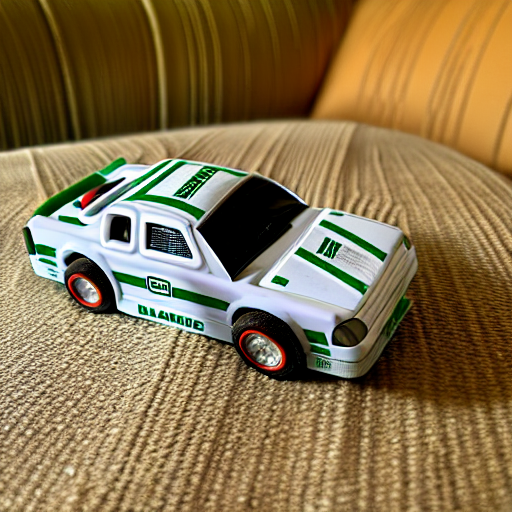

  0%|          | 0/50 [00:00<?, ?it/s]

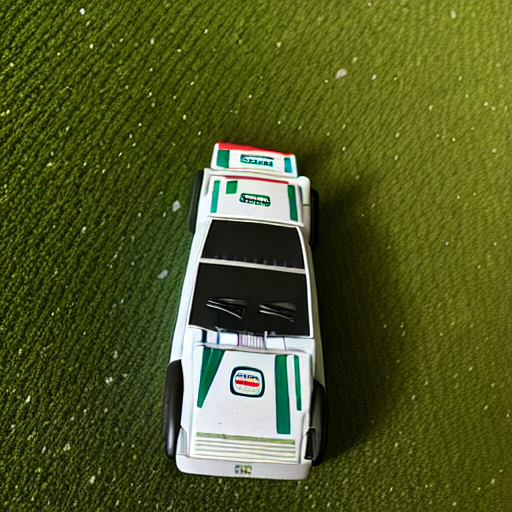

  0%|          | 0/50 [00:00<?, ?it/s]

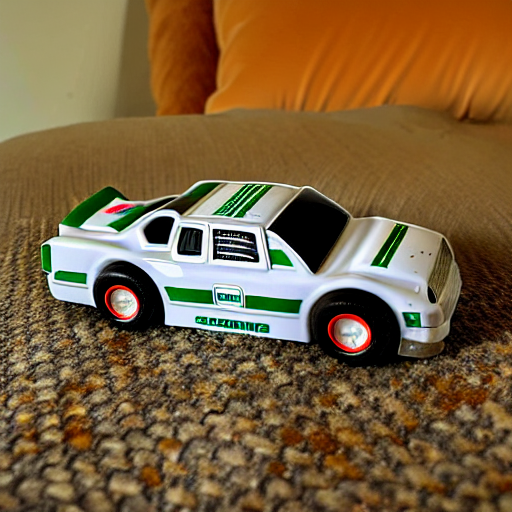

  0%|          | 0/50 [00:00<?, ?it/s]

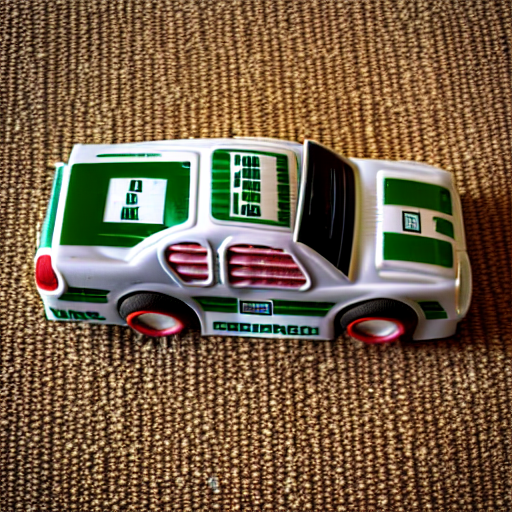

In [19]:
os.makedirs("results/dreambooth", exist_ok=True)

prompts = [
    "a photo of sks toycar on a table",
    "a photo of sks toycar in a garden",
    "a close-up photo of sks toycar",
    "a cartoon style image of sks toycar"
]

for i, prompt in enumerate(prompts, start=1):
    image = pipe(prompt).images[0]
    image.save(f"results/dreambooth/dreambooth_result{i}.png")
    display(image)

In [20]:
from google.colab import files

files.download("results/dreambooth/dreambooth_result1.png")
files.download("results/dreambooth/dreambooth_result2.png")
files.download("results/dreambooth/dreambooth_result3.png")
files.download("results/dreambooth/dreambooth_result4.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
files.download("dreambooth_lora_output/pytorch_lora_weights.safetensors")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>